ACME Insurance Inc. offers affordable health insurance to thousands of customer all over the United States. As the lead data scientist at ACME, you're tasked with creating an automated system to estimate the annual medical expenditure for new customers, using information such as their age, sex, BMI, children, smoking habits and region of residence.

Estimates from your system will be used to determine the annual insurance premium (amount paid every month) offered to the customer. Due to regulatory requirements, you must be able to explain why your system outputs a certain prediction.

You're given a CSV file containing verified historical data, consisting of the aforementioned information and the actual medical charges incurred by over 1300 customers.

In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install kagglehub

%pip install seaborn


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [117]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv(r'C:\Users\vijay\Downloads\insurance.csv')
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [118]:
#EDA
df.shape

(1338, 7)

In [119]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [120]:
df.describe()#gives only numeric data 

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [121]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

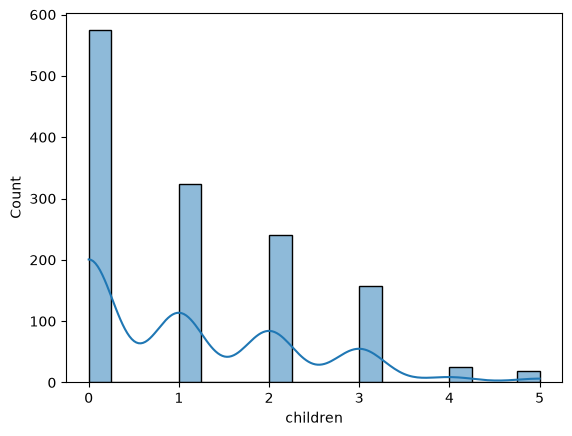

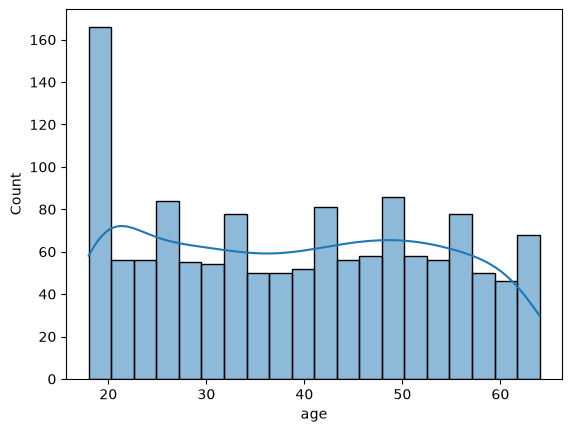

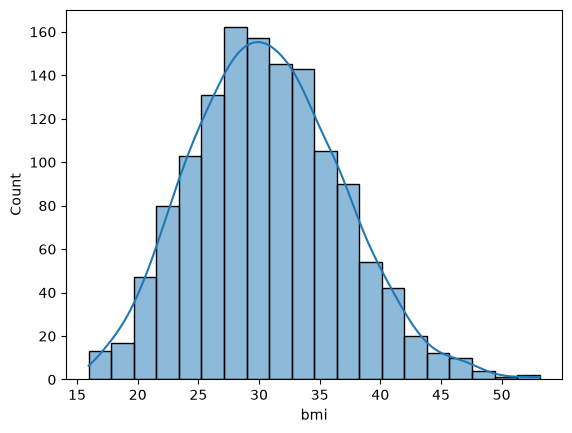

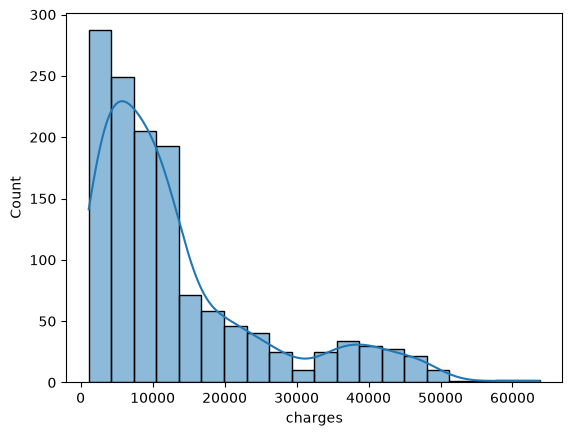

In [122]:
num_col={'age','bmi' ,'children','charges'} #to check distribution
for col in num_col:
    plt.figure()
    sns.histplot(df[col],kde = True,bins=20)
    


<Axes: xlabel='children', ylabel='count'>

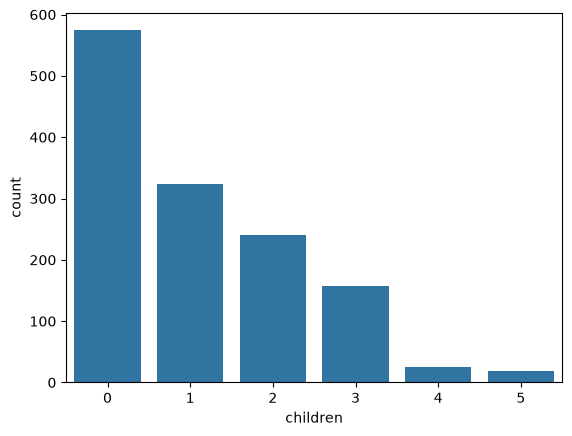

In [123]:
sns.countplot(x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

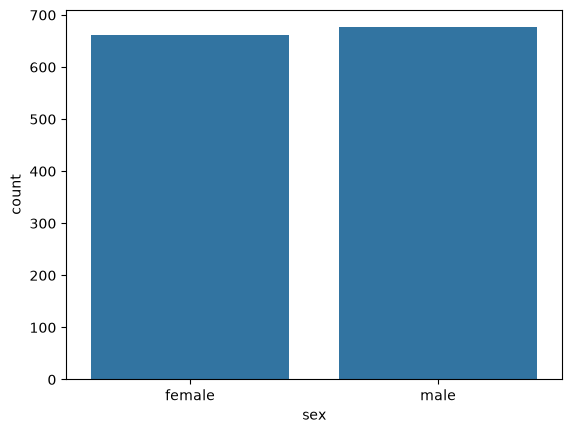

In [124]:
sns.countplot(x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

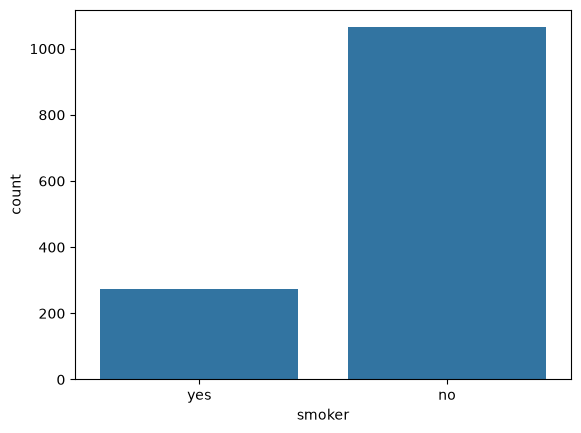

In [125]:
sns.countplot(x = df['smoker'])

In [126]:
# we were checking whitout connection but data analysis is not done without connection 
# now we do data analysis with a input and connecting an output 
# like does a smoker have less insurance price or more like that 
# we have to check because charges column is right skewed to make it correct
# we have to do data analysis


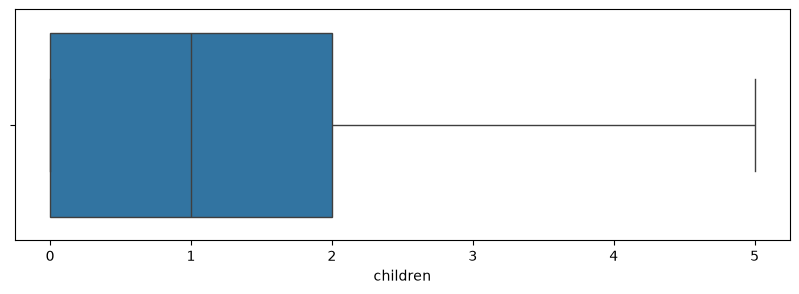

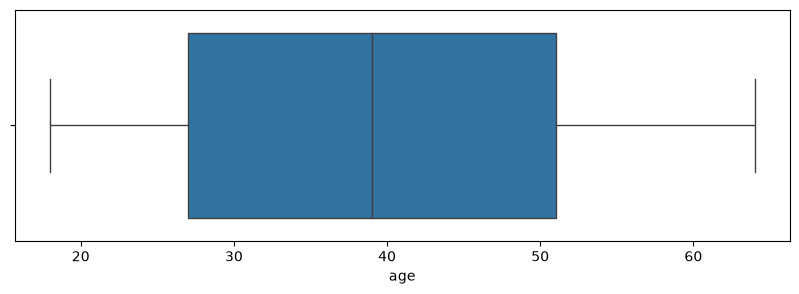

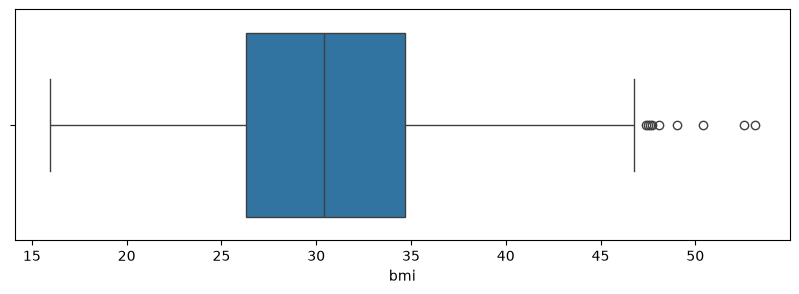

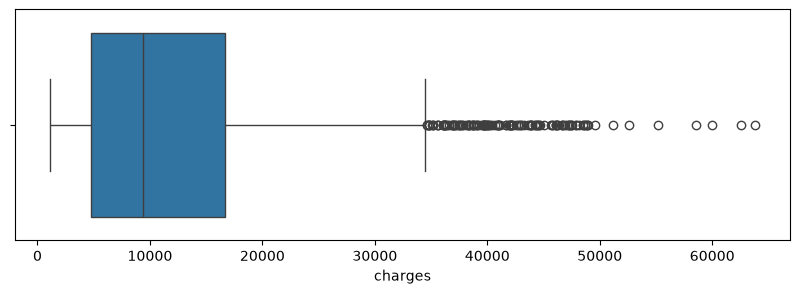

In [127]:
for col in num_col:
    plt.figure(figsize=(10,3))
    sns.boxplot(x=df[col])

<Axes: >

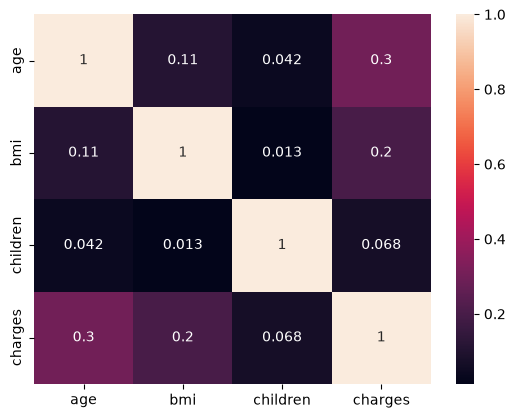

In [128]:
plt.figure(
    
)
sns.heatmap(df.corr(numeric_only=True),annot=True)

#data cleaning and preprocessing

In [129]:
df_clean=df.copy()

In [130]:
df_clean.drop_duplicates()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [131]:
df_clean.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [132]:
df_clean.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [133]:
df_clean['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [134]:
#convert male in 0 and female as 1

In [135]:
df_clean['sex']=df_clean['sex'].map({"male" :0,"female":1}) #label encodding

In [136]:
df_clean

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,no,northwest,10600.54830
1334,18,1,31.920,0,no,northeast,2205.98080
1335,18,1,36.850,0,no,southeast,1629.83350
1336,21,1,25.800,0,no,southwest,2007.94500


In [137]:
#convert smoker  yes in 0 and no as 1

In [138]:
df_clean['smoker']=df_clean['smoker'].map({"no" :0,"yes":1}) #label encodding

In [139]:
df_clean

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [140]:
df_clean.rename(columns={'sex':'is_female', 'smoker':'is_smoker'})

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [141]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [142]:
df_clean=pd.get_dummies(df_clean,columns=['region']) #one hot encoding

In [143]:
df_clean

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,False,True,False,False
1334,18,1,31.920,0,0,2205.98080,True,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,False,True


In [144]:
df_clean=df_clean.astype(int)

In [145]:
df_clean

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0
1334,18,1,31,0,0,2205,1,0,0,0
1335,18,1,36,0,0,1629,0,0,1,0
1336,21,1,25,0,0,2007,0,0,0,1




# feauture engineering and extraction



<Axes: xlabel='bmi', ylabel='Count'>

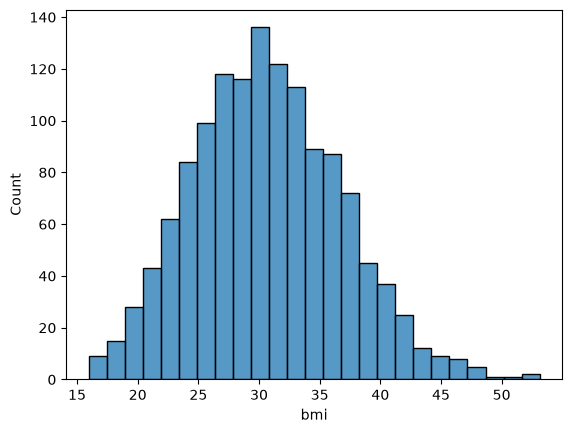

In [146]:
sns.histplot(df["bmi"])

In [147]:
df_clean["bmi_category"] = pd.cut(
    df_clean['bmi'],
    bins = [0, 18.5, 24.9, 29.9, float('inf')],
    labels=['underweight','normal','overweight','obese']
)

In [151]:
df_clean

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,0,1,False,False,True,False
1,18,0,33,1,0,1725,0,0,1,0,False,False,False,True
2,28,0,33,3,0,4449,0,0,1,0,False,False,False,True
3,33,0,22,0,0,21984,0,1,0,0,False,True,False,False
4,32,0,28,0,0,3866,0,1,0,0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,False,False,False,True
1334,18,1,31,0,0,2205,1,0,0,0,False,False,False,True
1335,18,1,36,0,0,1629,0,0,1,0,False,False,False,True
1336,21,1,25,0,0,2007,0,0,0,1,False,False,True,False


In [150]:
df_clean=pd.get_dummies(df_clean,columns=['bmi_category'])

KeyError: "None of [Index(['bmi_category'], dtype='str')] are in the [columns]"

In [155]:
df_clean=df_clean.astype(int)
df_clean

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,-1,1,0,0,1,16884,0,0,0,1,0,0,1,0
1,-1,0,0,0,0,1725,0,0,1,0,0,0,0,1
2,0,0,0,1,0,4449,0,0,1,0,0,0,0,1
3,0,0,-1,0,0,21984,0,1,0,0,0,1,0,0
4,0,0,0,0,0,3866,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0,0,0,1,0,10600,0,1,0,0,0,0,0,1
1334,-1,1,0,0,0,2205,1,0,0,0,0,0,0,1
1335,-1,1,0,0,0,1629,0,0,1,0,0,0,0,1
1336,-1,1,0,0,0,2007,0,0,0,1,0,0,1,0


In [73]:
df_clean.columns

Index(['age', 'sex', 'children', 'smoker', 'charges', 'region_northeast',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_underweight', 'bmi_category_normal',
       'bmi_category_overweight', 'bmi_category_obese', 'charges_bin'],
      dtype='str')

In [168]:
from sklearn.preprocessing import StandardScaler
cols = ['age','children','bmi']
scaler = StandardScaler()
df_clean[cols] = scaler.fit_transform(df_clean[cols])

#standardization or z-score normmalization
#It transforms the data so that each feature has a mean of 0 and a standard deviation of 1.

In [157]:
df_clean.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,-1.484353,1,0.019831,-0.371909,1,16884,0,0,0,1,0,0,1,0
1,-1.484353,0,0.019831,-0.371909,0,1725,0,0,1,0,0,0,0,1
2,0.041042,0,0.019831,1.534660,0,4449,0,0,1,0,0,0,0,1
3,0.041042,0,-1.454256,-0.371909,0,21984,0,1,0,0,0,1,0,0
4,0.041042,0,0.019831,-0.371909,0,3866,0,1,0,0,0,0,1,0


In [158]:
df_clean.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_underweight', 'bmi_category_normal',
       'bmi_category_overweight', 'bmi_category_obese'],
      dtype='str')

In [40]:

# noww all values are under 0 and 1 now we will do feauture extraction

"""The Pearson correlation coefficient is a statistical measure
that evaluates the strength and direction of the linear 
relationship between two continuous variables. 
Represented by the symbol r, it ranges from -1 to +1, 
indicating perfect negative and positive linear associations, 
respectively, while 0 signifies no linear relationship."""

'The Pearson correlation coefficient is a statistical measure\nthat evaluates the strength and direction of the linear \nrelationship between two continuous variables. \nRepresented by the symbol r, it ranges from -1 to +1, \nindicating perfect negative and positive linear associations, \nrespectively, while 0 signifies no linear relationship.'

In [170]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features = [
    'age',  'children', 'sex', 'smoker',
    'region_northwest', 'region_southeast', 'region_southwest','bmi_category_underweight',
    'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'
]

correlations = {
    feature: pearsonr(df_clean[feature], df_clean['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
3,smoker,0.787251
0,age,0.254519
10,bmi_category_obese,0.199533
5,region_southeast,0.073981
1,children,0.013441
4,region_northwest,-0.039905
6,region_southwest,-0.043210
7,bmi_category_underweight,-0.050484
2,sex,-0.057293
8,bmi_category_normal,-0.103679


This code performs **Pearson correlation analysis** to identify which features have the strongest linear relationships with insurance charges. Here's a detailed breakdown:

## **Code Explanation:**

### 1. **Import Statement**
from scipy.stats import pearsonr



- Imports the `pearsonr` function to calculate Pearson correlation coefficients

### 2. **Feature Selection**
selected_features = [
    'age', 'bmi', 'children', 'sex', 'smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'
]



- Creates a list of 11 features to analyze against insurance charges
- Includes demographics, lifestyle factors, geographic regions, and BMI categories

### 3. **Correlation Calculation**
correlations = {
    feature: pearsonr(df_clean[feature], df_clean['charges'])[0]
    for feature in selected_features
}



- **Dictionary comprehension** that calculates correlations for each feature
- `pearsonr()` returns a tuple: `(correlation_coefficient, p_value)`
- `[0]` extracts only the **correlation coefficient** (ignoring p-value)
- Results stored in a dictionary: `{'feature_name': correlation_value}`

### 4. **Results Organization**
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)



- Converts dictionary to a pandas DataFrame for better visualization
- Sorts features by correlation strength (highest to lowest)

## **Purpose:**
This analysis helps identify which factors most strongly predict insurance charges, with values closer to +1 or -1 indicating stronger linear relationships.

In [174]:
from scipy.stats import chi2_contingency
import pandas as pd

cat_features = [
    'sex', 'smoker',
    'region_northwest', 'region_southeast', 'region_southwest','region_northeast',
    'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'
]


alpha = 0.05

df_clean['charges_bin'] = pd.qcut(df_clean['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_clean[col], df_clean['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
smoker,854.020268,0.0,Reject Null (Keep Feature)
region_southeast,15.208814,0.001647,Reject Null (Keep Feature)
sex,9.532132,0.022992,Reject Null (Keep Feature)
bmi_category_obese,8.510101,0.036566,Reject Null (Keep Feature)
region_northeast,5.944573,0.114338,Accept Null (Drop Feature)
region_southwest,5.530825,0.136807,Accept Null (Drop Feature)
bmi_category_overweight,4.620089,0.201826,Accept Null (Drop Feature)
bmi_category_normal,3.578987,0.310661,Accept Null (Drop Feature)
region_northwest,1.226112,0.746749,Accept Null (Drop Feature)


This code performs a **Pearson correlation analysis** to measure the linear relationship between various features and insurance charges. Here's what each part does:

## Code Breakdown:

1. **Import**: `from scipy.stats import pearsonr` - imports the function to calculate Pearson correlation coefficients

2. **Feature Selection**: Creates a list of 14 features to analyze, including:
   - Demographics: age, sex, bmi, children
   - Lifestyle: smoker
   - Target variable: charges
   - Geographic regions: northeast, northwest, southeast, southwest
   - BMI categories: underweight, normal, overweight, obese

3. **Correlation Calculation**: 
   
   correlations = {
       feature: pearsonr(df_clean[feature], df_clean['charges'])
       for feature in selected_features
   }
   



   - Uses a dictionary comprehension to calculate Pearson correlation between each feature and 'charges'
   - `pearsonr()` returns both correlation coefficient and p-value

4. **Results Organization**:
   - Converts the dictionary to a pandas DataFrame with columns 'feature' and 'pearson correlation'
   - Sorts results by correlation strength in descending order

## Purpose:
This analysis helps identify which factors have the strongest linear relationships with insurance charges, allowing you to understand what drives insurance costs up or down. Features with higher absolute correlation values are more predictive of charges.

## **P-Value**
The **p-value** is the probability of getting your observed results (or more extreme) if there was actually no real relationship between variables.

- **Low p-value (< 0.05)**: Strong evidence that the relationship is real, not due to chance
- **High p-value (≥ 0.05)**: Weak evidence; the relationship might just be random noise

**Example**: If p-value = 0.02 for smoking vs. charges correlation, there's only a 2% chance this relationship happened by random luck.

## **Chi-Square (χ²) Statistic**
The **chi-square statistic** tests whether two categorical variables are independent or related.

- **High χ² value**: Variables are likely related
- **Low χ² value**: Variables are likely independent
- Always paired with a p-value for interpretation

**Example**: Testing if smoking status (yes/no) is related to insurance region (northeast/southwest/etc.)

## **Decision**
The **decision** is your conclusion based on the statistical test:

- **Reject the null hypothesis**: "There IS a significant relationship" (when p < 0.05)
- **Fail to reject the null hypothesis**: "There is NOT enough evidence of a relationship" (when p ≥ 0.05)

## **In Your Correlation Code Context:**
Your `pearsonr()` function returns both:
1. **Correlation coefficient** (-1 to +1): strength and direction of linear relationship
2. **P-value**: whether that correlation is statistically significant

This helps you decide which features truly matter for predicting insurance charges!

In [237]:
final_df = df_clean[['age', 'sex', 'bmi', 'children', 'smoker', 'charges','region_southeast','region_northeast','region_southwest','region_northwest','bmi_category_obese'
                ]]

In [238]:
final_df

,age,sex,bmi,children,smoker,charges,region_southeast,region_northeast,region_southwest,region_northwest,bmi_category_obese
0,-1.484353,1,0.019831,-0.371909,1,16884,0,0,1,0,0
1,-1.484353,0,0.019831,-0.371909,0,1725,1,0,0,0,1
2,0.041042,0,0.019831,1.534660,0,4449,1,0,0,0,1
3,0.041042,0,-1.454256,-0.371909,0,21984,0,0,0,1,0
4,0.041042,0,0.019831,-0.371909,0,3866,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
1333,0.041042,0,0.019831,1.534660,0,10600,0,0,0,1,1
1334,-1.484353,1,0.019831,-0.371909,0,2205,0,1,0,0,1
1335,-1.484353,1,0.019831,-0.371909,0,1629,1,0,0,0,1
1336,-1.484353,1,0.019831,-0.371909,0,2007,0,0,1,0,0


In [239]:
"""
This method is called **"train-test split"** or **"holdout validation"**.

It's a fundamental machine learning technique where you:
- Split your dataset into separate training and testing portions
- Train your model on the training set
- Evaluate the model's performance on the unseen test set

This approach helps assess how well your model will generalize to new, unseen data and 
helps detect overfitting. 
The specific implementation using `train_test_split()` from scikit-learn is the most common way 
to perform this split in Python."""


from sklearn.model_selection import train_test_split

X = final_df.drop('charges',axis=1)
y = final_df['charges']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[3153.19, 0.58, 301.02,...,-355.61, 64.49,4249.06]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['age','sex','bmi',...,'region_southwest','region_northwest', 'bmi_category_obese']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6235
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,9


In [240]:
y_pred=model.predict(X_test)

In [241]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_pred)
print((r2*100),"%")
n=X_test.shape[0]
p=X_test.shape[1]
adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
print((adjusted_r2*100),"%")
#performance metrics

76.14855608866655 %
75.22048434114384 %


In [242]:
y_test

764      9095
887      5272
890     29330
1293     9301
259     33750
        ...  
109     47055
575     12222
535      6067
543     63770
846      9872
Name: charges, Length: 268, dtype: int64